Figure S16: GWAS pleiotropy. A For all credible set groups that colocalize with at least one GWAS hit, the maximum PIP-weighted | log2aFC | for any single gene in the cluster, split by whether or not the credible set group colocalizes with more than one GWAS hit (p=0.38). B For all credible set groups that colocalize with at least one GWAS hit, the CV of PIP-weighted | log2aFC | across genes in the cluster (quantifying how concentrated vs distributed the effect is) split by whether or not the credible set group colocalizes with multiple GWAS hits (p=0.023), p-values from two-sample t-test.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm
tqdm.pandas()

# get outputs from a config file
import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *

# Set up plotting
plt.rcParams.update({'font.size': 10})
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

# Load tissue data
tissue_df = load_tissue_df(config)
tissue_ids = load_tissue_ids(config)

Using Python: /home/klawren/.pixi/envs/python/bin/python


In [2]:
# load in variant-level aFC
pcqtl_afc = load_across_tissues(config, load_pc_afc)
eqqtl_afc = load_across_tissues(config, load_e_afc)
qtl_afc = pd.concat([pcqtl_afc, eqqtl_afc]).drop_duplicates(['tissue_id', 'pid', 'sid']).reset_index(drop=True)

# load in credible sets
pcqtl_susie = load_across_tissues(config, load_pc_susie)
pcqtl_susie['cluster_id'] = pcqtl_susie['phenotype_id'].str.split('_pc').str[0]
pcqtl_susie['gene_id'] = pcqtl_susie['cluster_id'].str.split('_')
eqtl_susie = load_across_tissues(config, load_e_susie)
eqtl_susie['cluster_id'] = eqtl_susie['phenotype_id'].str.split('_e').str[0]
eqtl_susie['gene_id'] = eqtl_susie['cluster_id'].str.split('_')
susie = pd.concat([pcqtl_susie, eqtl_susie], keys=['pcQTL', 'eQTL'], names=['qtl_type']).reset_index()
susie_explode = susie.explode('gene_id')

# merge in afc information
susie_explode_afc = pd.merge(susie_explode, qtl_afc[['pid', 'sid', 'tissue_id', 'log2_aFC']], left_on=['gene_id', 'variant_id', 'tissue_id'], 
    right_on=['pid', 'sid', 'tissue_id'], how='left')

# pip-weighted afc over credible set
susie_explode_afc['pip_afc'] = susie_explode_afc['pip'] * susie_explode_afc['log2_aFC']
credible_set_grouped_afc = susie_explode_afc.groupby(['phenotype_id', 'cs_id', 'tissue_id', 'gene_id', 'qtl_type']).agg({'pip_afc':'sum', 'pip':'sum'}).reset_index()
credible_set_grouped_afc['pip_afc_weighted'] = credible_set_grouped_afc['pip_afc']/credible_set_grouped_afc['pip']
credible_set_grouped_afc['abs_pip_afc_weighted'] = credible_set_grouped_afc['pip_afc_weighted'].abs()

# group over genes in a cluster that a credible set impacts
cluster_grouped_afc = credible_set_grouped_afc.groupby(['tissue_id', 'phenotype_id', 'cs_id', 'qtl_type']).agg(
    max_afc=('abs_pip_afc_weighted', 'max'),
    mean_afc=('abs_pip_afc_weighted', 'mean'), 
    std_afc=('abs_pip_afc_weighted', 'std')).reset_index()

cluster_grouped_afc['cv_afc'] = cluster_grouped_afc['std_afc']/cluster_grouped_afc['mean_afc'] * 100

In [3]:
# load in gwas signal groups
gwas_signal_groups = load_across_tissues(config, load_gwas_signal_groups)

gwas_signal_groups['phenotype_cs_id'] = gwas_signal_groups['signal_id'].str.split('-')
gwas_signal_groups_exploded = gwas_signal_groups.explode('phenotype_cs_id')

# get just the qtl phenotypes
gwas_signal_groups_qtl_pheno_exploded = gwas_signal_groups_exploded[~gwas_signal_groups_exploded['phenotype_cs_id'].str.contains('gwas')]
gwas_signal_groups_qtl_pheno_exploded['cs_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[1].str.split('_cluster').str[0].astype(int)
gwas_signal_groups_qtl_pheno_exploded['phenotype_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[0]

# merge in aFC information
gwas_signal_groups_afc = pd.merge(gwas_signal_groups_qtl_pheno_exploded, cluster_grouped_afc, on=['tissue_id', 'phenotype_id', 'cs_id'], how='left')
gwas_signal_groups_afc['has_gwas'] = gwas_signal_groups_afc['num_gwas_coloc'] > 0
gwas_signal_groups_afc['has_multiple_gwas'] = gwas_signal_groups_afc['num_gwas_coloc'] > 1

/local/scratch/klawren/slrmtmp.49273183/ipykernel_5565/1253346807.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_signal_groups_qtl_pheno_exploded['cs_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotype_cs_id'].str.split('_cs_').str[1].str.split('_cluster').str[0].astype(int)
/local/scratch/klawren/slrmtmp.49273183/ipykernel_5565/1253346807.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gwas_signal_groups_qtl_pheno_exploded['phenotype_id'] = gwas_signal_groups_qtl_pheno_exploded['phenotyp

/local/scratch/klawren/slrmtmp.49273183/ipykernel_5565/1174253094.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['1 GWAS', '>1 GWAS'])
/local/scratch/klawren/slrmtmp.49273183/ipykernel_5565/1174253094.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['1 GWAS', '>1 GWAS'])


False, True p=3.79e-01
False, True p=2.27e-02


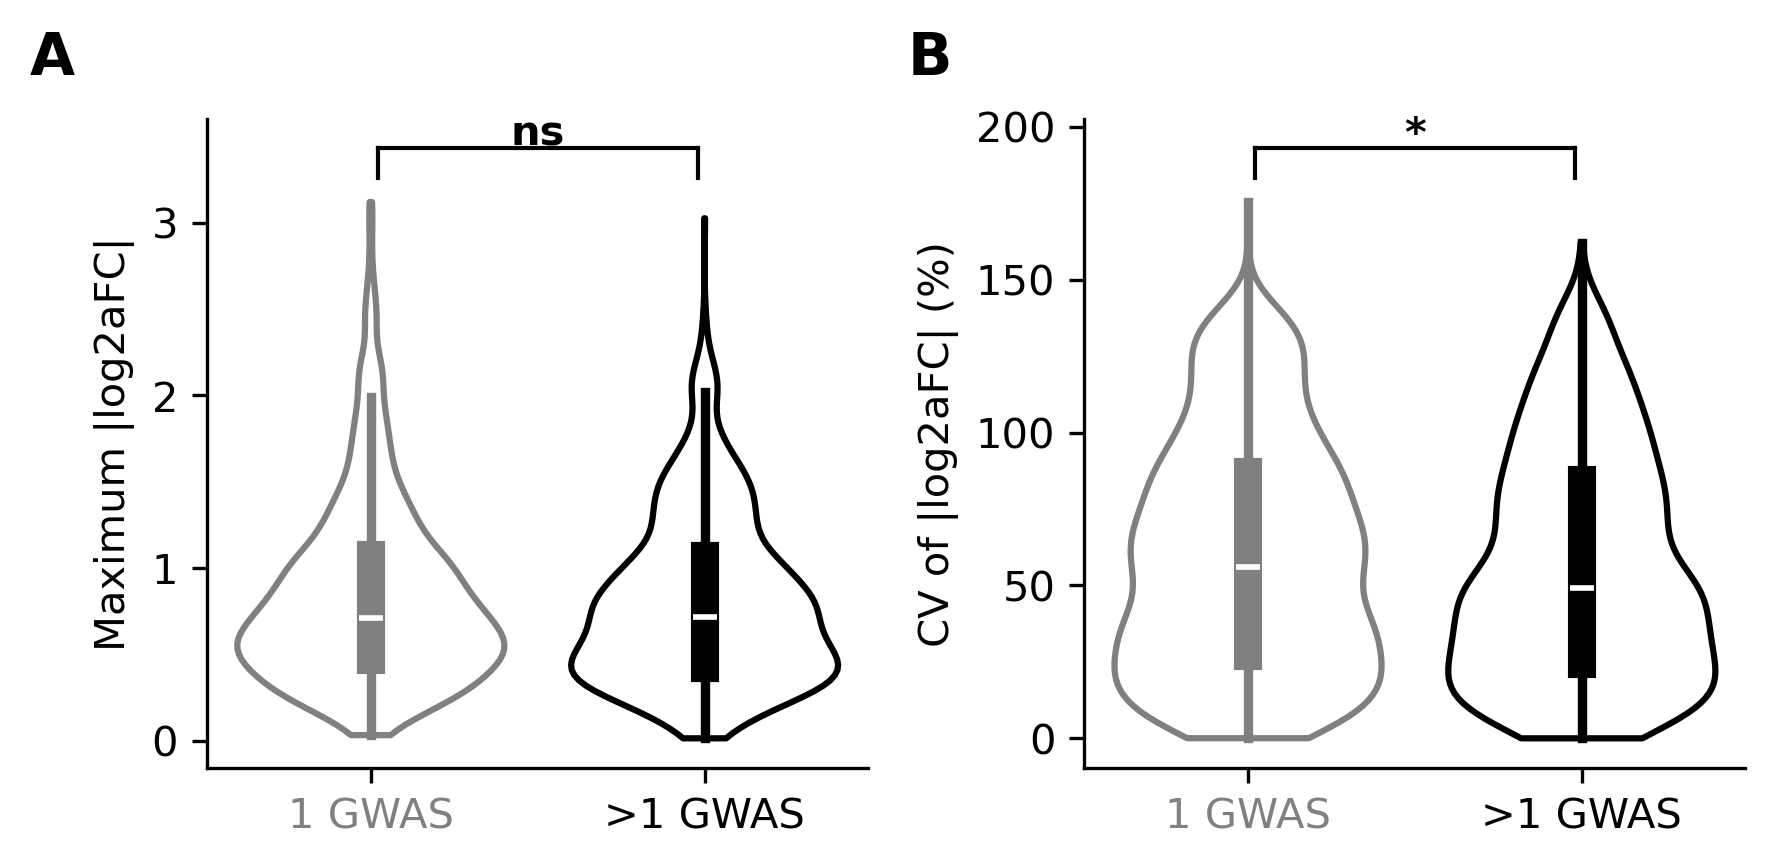

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, dpi=300)

# Panel A: Maximum single-gene abs(aFC)
sns.violinplot(
    data=gwas_signal_groups_afc[gwas_signal_groups_afc['has_gwas']],
    x='has_multiple_gwas',
    y='max_afc',
    hue='has_multiple_gwas',
    palette=['grey', 'k'],
    ax=axes[0],
    cut=0,
    inner='box',
    linewidth=1.5,
    saturation=0.8,
    fill=False,
    legend=False
)
axes[0].spines[['right', 'top']].set_visible(False)
axes[0].set_ylabel('Maximum |log2aFC|')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['1 GWAS', '>1 GWAS'])
axes[0].text(-.2, 1.05, 'A', transform=axes[0].transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')

add_statistical_significance(
    axes[0],
    gwas_signal_groups_afc[gwas_signal_groups_afc['has_gwas']],
    'has_multiple_gwas',
    'max_afc',
    palette=['grey', 'k']
)

for i, tick_label in enumerate(axes[0].get_xticklabels()):
    tick_label.set_color(['grey', 'k'][i])

# Panel B: CV of abs(aFC)
sns.violinplot(
    data=gwas_signal_groups_afc[gwas_signal_groups_afc['has_gwas']],
    x='has_multiple_gwas',
    y='cv_afc',
    hue='has_multiple_gwas',
    palette=['grey', 'k'],
    ax=axes[1],
    cut=0,
    inner='box',
    linewidth=1.5,
    saturation=0.8,
    fill=False,
    legend=False
)
axes[1].spines[['right', 'top']].set_visible(False)
axes[1].set_ylabel('CV of |log2aFC| (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['1 GWAS', '>1 GWAS'])
axes[1].text(-.2, 1.05, 'B', transform=axes[1].transAxes, fontsize=14, fontweight='bold', 
          ha='right', va='bottom')
add_statistical_significance(
    axes[1],
    gwas_signal_groups_afc[gwas_signal_groups_afc['has_gwas']],
    'has_multiple_gwas',
    'cv_afc',
    palette=['grey', 'k']
)

for i, tick_label in enumerate(axes[1].get_xticklabels()):
    tick_label.set_color(['grey', 'k'][i])

# Save the combined figure
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s16.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()